## **DATA SET PREPARATION**

In [ ]:
import pandas as pd
import glob
import os
import io

path = '/content/drive/MyDrive/Colab Notebooks/Sheryar/Training'

csv_files = glob.glob(os.path.join(path, "*.csv"))

data_dict = {}
target_cols = ['B1', 'B2', 'B3', 'B4']

for f in csv_files:
    df_name = os.path.splitext(os.path.basename(f))[0]
    print(f"Processing: {df_name}")

    try:
        with open(f, 'r') as file:
            lines = file.readlines()

        header_line = lines[7].lstrip(';').strip()

        data_lines = [line.strip() for line in lines[9:]]


        csv_content = "\n".join([header_line] + data_lines)


        df = pd.read_csv(io.StringIO(csv_content), sep=',', skipinitialspace=True)
        available_cols = [col for col in target_cols if col in df.columns]
        data_dict[df_name] = df[available_cols]

        print(f"  Successfully loaded {df_name} with shape: {data_dict[df_name].shape}")
        if not data_dict[df_name].empty:
             display(data_dict[df_name].head(2))
    except Exception as e:
        print(f"  Error processing {f}: {e}")

print(f"\nCreated {len(data_dict)} separate DataFrames.")

Processing: urban
  Successfully loaded urban with shape: (495553, 4)


,B1,B2,B3,B4
0,298,332,261,263
1,305,343,271,272


Processing: water
  Successfully loaded water with shape: (386814, 4)


,B1,B2,B3,B4
0,235,251,186,185
1,236,250,187,177


Processing: road
  Successfully loaded road with shape: (69203, 4)


...

Processing: tesstt
  Successfully loaded tesstt with shape: (0, 4)
Processing: cpf-253
  Successfully loaded cpf-253 with shape: (133030, 4)


,B1,B2,B3,B4
0,244,262,189,243
1,244,263,188,247


Processing: sl-284
  Successfully loaded sl-284 with shape: (232509, 4)


,B1,B2,B3,B4
0,247,261,188,257
1,251,266,191,263



Created 6 separate DataFrames.


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

all_dfs = []
MAX_PIXELS_PER_CLASS = 133000

print("Processing individual dataframes for pixel limit and class labeling...")
for class_name, df in data_dict.items():
    if len(df) > MAX_PIXELS_PER_CLASS:
        df_sampled = df.sample(n=MAX_PIXELS_PER_CLASS, random_state=42).copy() # Use random_state for reproducibility
        print(f"  Class '{class_name}' sampled from {len(df)} to {MAX_PIXELS_PER_CLASS} pixels.")
    else:
        df_sampled = df.copy()
        print(f"  Class '{class_name}' (size: {len(df)}) kept as is.")
    df_sampled['class'] = class_name
    all_dfs.append(df_sampled)

final_df = pd.concat(all_dfs, ignore_index=True)
print(f"\nCombined final_df created with shape: {final_df.shape}")
print("First 5 rows of final_df with class labels (strings):")
display(final_df.head())

bands_df = final_df[['B1', 'B2', 'B3', 'B4']].copy()

B = bands_df['B1']
G = bands_df['B2']
R = bands_df['B3']
NIR = bands_df['B4']

bands_df['GNDVI'] = (NIR - G) / (NIR + G + 1e-6)

bands_df['EVI'] = 2.5 * ((NIR - R) / (NIR + 6 * R - 7.5 * B + 1 + 1e-6))

bands_df['SAVI'] = ((NIR - R) * (1 + 0.5)) / (NIR + R + 0.5 + 1e-6)

engineered_df = bands_df

print(f"\nDataFrame after feature engineering: {engineered_df.shape}")
print("First 5 rows of engineered_df before normalization:")
display(engineered_df.head())

feature_cols = ['B1', 'B2', 'B3', 'B4', 'GNDVI', 'EVI', 'SAVI']

scaler = StandardScaler()

engineered_df[feature_cols] = scaler.fit_transform(engineered_df[feature_cols])

print(f"\nDataFrame after normalization: {engineered_df.shape}")
print("First 5 rows of engineered_df after normalization:")
display(engineered_df.head())

engineered_df['class'] = final_df['class']
label_encoder = LabelEncoder()
engineered_df['class'] = label_encoder.fit_transform(engineered_df['class'])

print(f"\nFinal DataFrame with engineered and normalized features and INTEGER class labels: {engineered_df.shape}")
print("First 5 rows of the final engineered DataFrame:")
display(engineered_df.head())
print(f"\nMapping of original class names to integer labels: {list(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

Processing individual dataframes for pixel limit and class labeling...
  Class 'urban' sampled from 495553 to 133000 pixels.
  Class 'water' sampled from 386814 to 133000 pixels.
  Class 'road' (size: 69203) kept as is.
  Class 'tesstt' (size: 0) kept as is.
  Class 'cpf-253' sampled from 133030 to 133000 pixels.
  Class 'sl-284' sampled from 232509 to 133000 pixels.

Combined final_df created with shape: (601203, 5)
First 5 rows of final_df with class labels (strings):


,B1,B2,B3,B4,class
0,295,328,256,250,urban
1,309,356,290,294,urban
2,272,297,231,229,urban
3,267,293,232,230,urban
4,286,323,260,261,urban



DataFrame after feature engineering: (601203, 7)
First 5 rows of engineered_df before normalization:


,B1,B2,B3,B4,GNDVI,EVI,SAVI
0,295,328,256,250,-0.134948,0.035253,-0.017769
1,309,356,290,294,-0.095385,-0.035398,0.010265
2,272,297,231,229,-0.129278,0.011792,-0.006515
3,267,293,232,230,-0.120459,0.013175,-0.006486
4,286,323,260,261,-0.106164,-0.00774,0.002876



DataFrame after normalization: (601203, 7)
First 5 rows of engineered_df after normalization:


,B1,B2,B3,B4,GNDVI,EVI,SAVI
0,1.789503,1.760431,1.705475,0.636244,-0.572182,0.816080,-0.777244
1,2.371835,2.634910,2.775345,1.836813,-0.029561,0.486165,-0.564209
2,0.832817,0.792257,0.918805,0.063245,-0.494409,0.706529,-0.691721
3,0.624841,0.667331,0.950272,0.090531,-0.373459,0.712986,-0.691507
4,1.415148,1.604274,1.831342,0.936386,-0.177408,0.615320,-0.620358



Final DataFrame with engineered and normalized features and INTEGER class labels: (601203, 8)
First 5 rows of the final engineered DataFrame:


,B1,B2,B3,B4,GNDVI,EVI,SAVI,class
0,1.789503,1.760431,1.705475,0.636244,-0.572182,0.816080,-0.777244,3
1,2.371835,2.634910,2.775345,1.836813,-0.029561,0.486165,-0.564209,3
2,0.832817,0.792257,0.918805,0.063245,-0.494409,0.706529,-0.691721,3
3,0.624841,0.667331,0.950272,0.090531,-0.373459,0.712986,-0.691507,3
4,1.415148,1.604274,1.831342,0.936386,-0.177408,0.615320,-0.620358,3



Mapping of original class names to integer labels: [('cpf-253', np.int64(0)), ('road', np.int64(1)), ('sl-284', np.int64(2)), ('urban', np.int64(3)), ('water', np.int64(4))]


### **SVM**


--- Model Hyperparameters (SVM) ---
Random State: 42
Test Size: 0.2
Kernel: rbf
C (Regularization parameter): 1.0
Gamma (Kernel coefficient): scale
SVM Training Sample Fraction: 0.1
-------------------------------

Sampling 10% of the training data for SVM...
Original Training data shape: (480962, 7)
SVM Training data shape (after sampling): (48096, 7)
Test data shape: (120241, 7)

Training Support Vector Machine (SVM) Model...
Model training complete.


--- Overall Accuracy (OA) and Kappa Score ---


,Training Set,Test Set
Metric,,
Overall Accuracy,0.883288,0.883251
Kappa Score,0.852286,0.852240



=== Training Set Performance (Full Training Set) ===
Classification Report:
              precision    recall  f1-score   support

     cpf-253       0.80      0.84      0.82    106400
        road       0.88      0.82      0.85     55362
      sl-284       0.81      0.85      0.83    106400
       urban       0.95      0.94      0.94    106400
       water       0.99      0.95      0.97    106400

    accuracy                           0.88    480962
   macro avg       0.89      0.88      0.88    480962
weighted avg       0.89      0.88      0.88    480962


=== Test Set Performance ===
Classification Report:
              precision    recall  f1-score   support

     cpf-253       0.80      0.84      0.82     26600
        road       0.88      0.82      0.85     13841
      sl-284       0.81      0.85      0.83     26600
       urban       0.95      0.93      0.94     26600
       water       0.99      0.95      0.97     26600

    accuracy                           0.88    120241
 

,Precision,Recall,F1-Score
Class,,,
cpf-253,0.798325,0.838496,0.817918
road,0.881684,0.818793,0.849075
sl-284,0.809057,0.846438,0.827326
urban,0.949633,0.935103,0.942312
water,0.990355,0.946673,0.968021



--- Per-class Performance (Test Set) ---


,Precision,Recall,F1-Score
Class,,,
cpf-253,0.799964,0.838759,0.818903
road,0.881873,0.819305,0.849438
sl-284,0.807108,0.846128,0.826157
urban,0.948905,0.934850,0.941825
water,0.991260,0.946541,0.968385


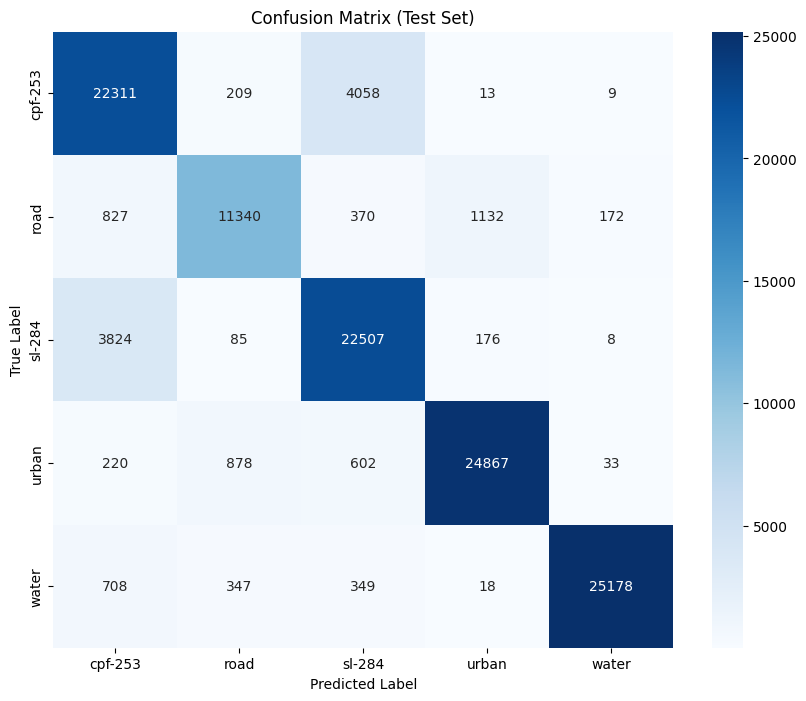

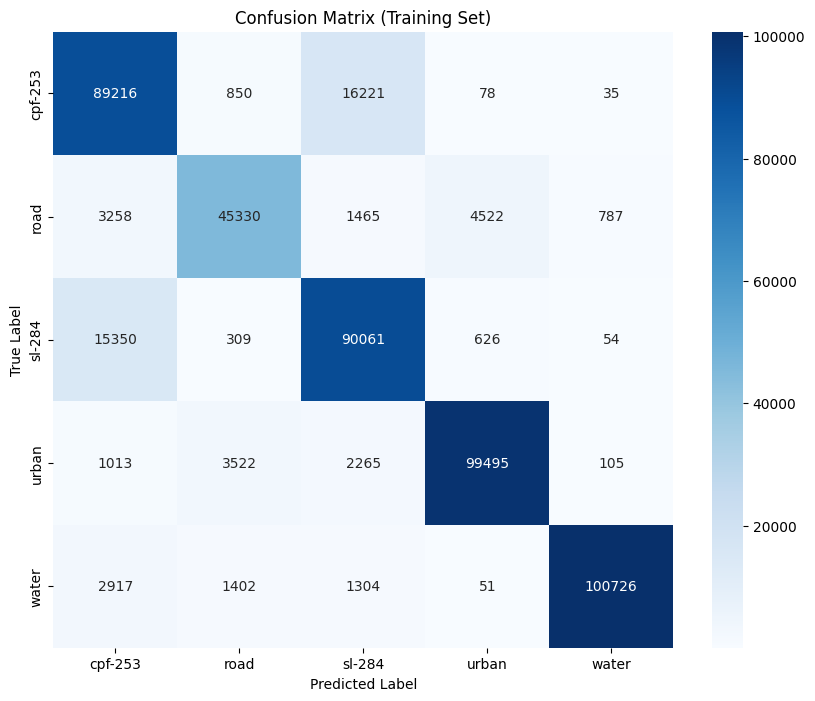

  Sampling 10% of the test data for permutation importance: 12024 samples.


Feature Importance Table (Test Set) -- Model: SVM


,Feature,Importance Mean,Importance Std
4,GNDVI,0.406354,0.002412
2,B3,0.360986,0.003202
0,B1,0.267008,0.001954
6,SAVI,0.259232,0.000832
3,B4,0.206171,0.001996
1,B2,0.193945,0.001164
5,EVI,0.109988,0.000956


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, cohen_kappa_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance


RANDOM_STATE = 42
TEST_SIZE = 0.20


KERNEL = 'rbf'
C_PARAM = 1.0
GAMMA = 'scale'

SVM_TRAIN_SAMPLE_FRACTION = 0.1

print("\n--- Model Hyperparameters (SVM) ---")
hyperparams = {
    "Random State": RANDOM_STATE,
    "Test Size": TEST_SIZE,
    "Kernel": KERNEL,
    "C (Regularization parameter)": C_PARAM,
    "Gamma (Kernel coefficient)": GAMMA,
    "SVM Training Sample Fraction": SVM_TRAIN_SAMPLE_FRACTION
}
for param, value in hyperparams.items():
    print(f"{param}: {value}")
print("-------------------------------\n")

feature_cols = ['B1', 'B2', 'B3', 'B4', 'GNDVI', 'EVI', 'SAVI']
X = engineered_df[feature_cols]
y = engineered_df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_train_scaled = X_train
X_test_scaled = X_test

if SVM_TRAIN_SAMPLE_FRACTION < 1.0:
    print(f"Sampling {SVM_TRAIN_SAMPLE_FRACTION*100:.0f}% of the training data for SVM...")

    X_train_sampled, _, y_train_sampled, _ = train_test_split(
        X_train_scaled, y_train, train_size=SVM_TRAIN_SAMPLE_FRACTION, random_state=RANDOM_STATE, stratify=y_train
    )
else:
    X_train_sampled = X_train_scaled
    y_train_sampled = y_train

print(f"Original Training data shape: {X_train_scaled.shape}")
print(f"SVM Training data shape (after sampling): {X_train_sampled.shape}")
print(f"Test data shape: {X_test_scaled.shape}\n")

svm_model = SVC(
    kernel=KERNEL,
    C=C_PARAM,
    gamma=GAMMA,
    random_state=RANDOM_STATE,
)

print("Training Support Vector Machine (SVM) Model...")
svm_model.fit(X_train_sampled, y_train_sampled)
print("Model training complete.\n")

if 'label_encoder' in globals():
    target_names = label_encoder.classes_
else:
    target_names = [str(i) for i in sorted(y.unique())]
    print("Warning: label_encoder not found. Using numeric class names for evaluation.")

y_train_pred = svm_model.predict(X_train_scaled)

y_test_pred = svm_model.predict(X_test_scaled)

print("\n--- Overall Accuracy (OA) and Kappa Score ---")
oa_train = accuracy_score(y_train, y_train_pred)
oa_test = accuracy_score(y_test, y_test_pred)

kappa_train = cohen_kappa_score(y_train, y_train_pred)
kappa_test = cohen_kappa_score(y_test, y_test_pred)

accuracy_data = {
    "Metric": ["Overall Accuracy", "Kappa Score"],
    "Training Set": [oa_train, kappa_train],
    "Test Set": [oa_test, kappa_test]
}
accuracy_df = pd.DataFrame(accuracy_data).set_index("Metric")
display(accuracy_df)

print("\n=== Training Set Performance (Full Training Set) ===")
print("Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=target_names))

print("\n=== Test Set Performance ===")
print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=target_names))

precision_train, recall_train, f1_train, _ = precision_recall_fscore_support(y_train, y_train_pred, labels=range(len(target_names)), average=None)
per_class_train_df = pd.DataFrame({
    'Class': target_names,
    'Precision': precision_train,
    'Recall': recall_train,
    'F1-Score': f1_train
}).set_index('Class')
print("\n--- Per-class Performance (Training Set) ---")
display(per_class_train_df)

precision_test, recall_test, f1_test, _ = precision_recall_fscore_support(y_test, y_test_pred, labels=range(len(target_names)), average=None)
per_class_test_df = pd.DataFrame({
    'Class': target_names,
    'Precision': precision_test,
    'Recall': recall_test,
    'F1-Score': f1_test
}).set_index('Class')
print("\n--- Per-class Performance (Test Set) ---")
display(per_class_test_df)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Training Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

perm_test_fraction = 0.1
X_test_perm, _, y_test_perm, _ = train_test_split(
    X_test_scaled, y_test, train_size=perm_test_fraction, random_state=RANDOM_STATE, stratify=y_test
)
print(f"  Sampling {perm_test_fraction*100:.0f}% of the test data for permutation importance: {X_test_perm.shape[0]} samples.\n")

perm_importance = permutation_importance(svm_model, X_test_perm, y_test_perm, n_repeats=2, random_state=RANDOM_STATE, n_jobs=-1)

feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
}).sort_values(by='Importance Mean', ascending=False)

print("\nFeature Importance Table (Test Set) -- Model: SVM")
display(feature_importance_df)

/tmp/ipykernel_799/4019358123.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


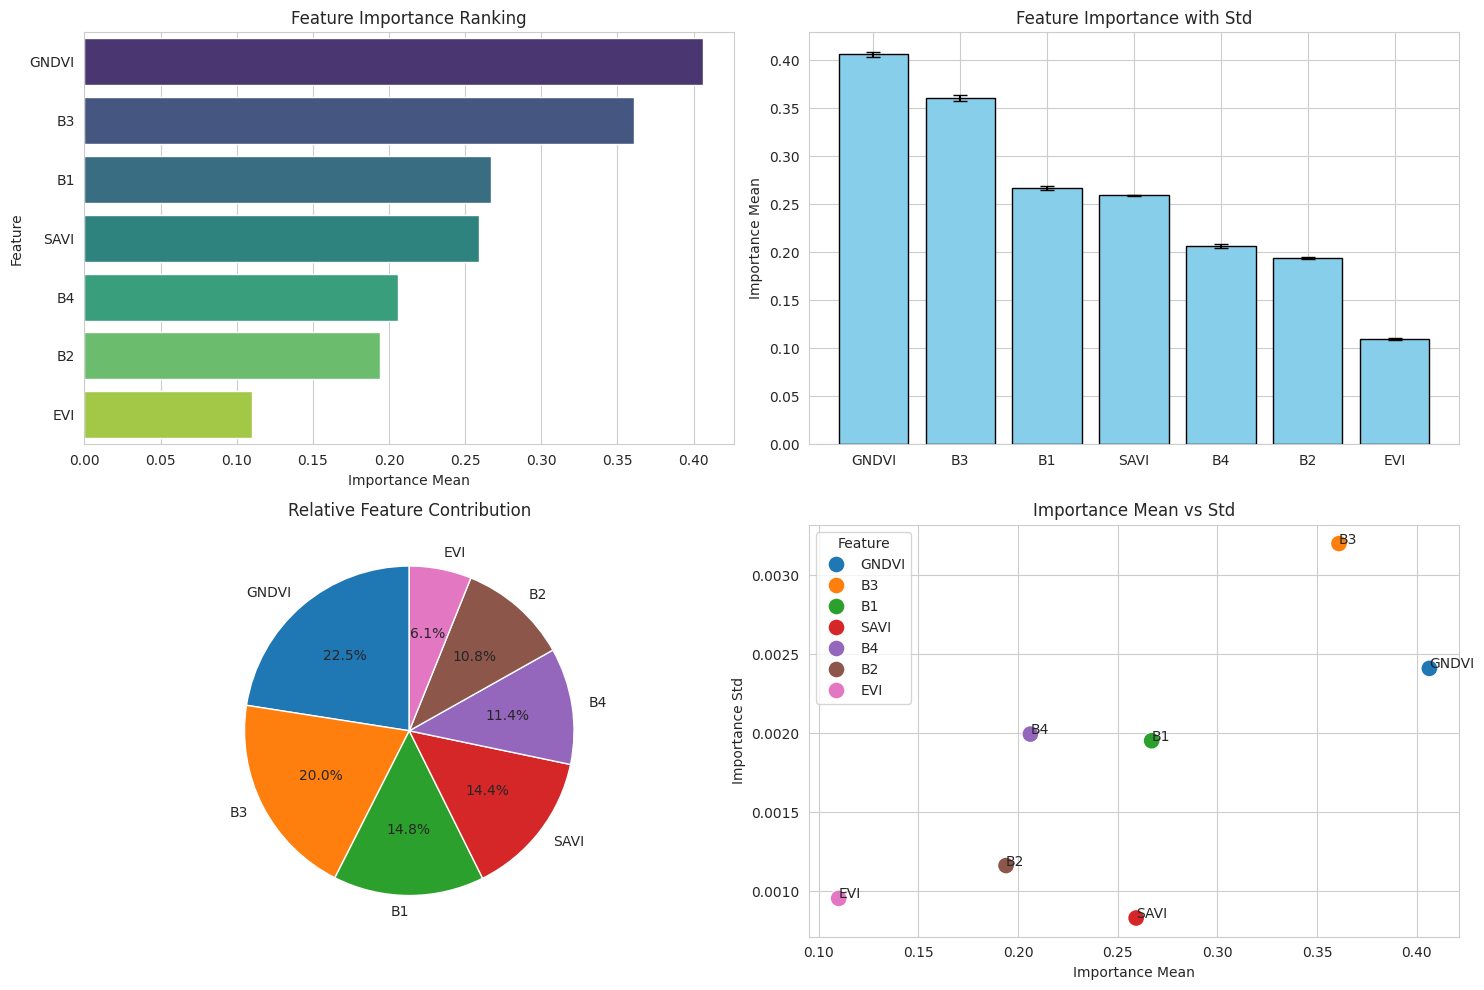

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame({
    "Feature": ["GNDVI", "B3", "B1", "SAVI", "B4", "B2", "EVI"],
    "Importance Mean": [0.406354, 0.360986, 0.267008, 0.259232, 0.206171, 0.193945, 0.109988],
    "Importance Std": [0.002412, 0.003202, 0.001954, 0.000832, 0.001996, 0.001164, 0.000956]
})

df = df.sort_values(by="Importance Mean", ascending=False)

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(
    data=df,
    y="Feature",
    x="Importance Mean",
    palette="viridis",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Feature Importance Ranking")
axes[0, 0].set_xlabel("Importance Mean")
axes[0, 1].bar(
    df["Feature"],
    df["Importance Mean"],
    yerr=df["Importance Std"],
    capsize=5,
    color="skyblue",
    edgecolor="black"
)
axes[0, 1].set_title("Feature Importance with Std")
axes[0, 1].set_ylabel("Importance Mean")
axes[1, 0].pie(
    df["Importance Mean"],
    labels=df["Feature"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1, 0].set_title("Relative Feature Contribution")
sns.scatterplot(
    data=df,
    x="Importance Mean",
    y="Importance Std",
    hue="Feature",
    s=150,
    palette="tab10",
    ax=axes[1, 1]
)

for i in range(len(df)):
    axes[1, 1].text(
        df["Importance Mean"].iloc[i],
        df["Importance Std"].iloc[i],
        df["Feature"].iloc[i]
    )

axes[1, 1].set_title("Importance Mean vs Std")
axes[1, 1].set_xlabel("Importance Mean")
axes[1, 1].set_ylabel("Importance Std")

plt.tight_layout()
plt.show()

In [ ]:
training_error = 1 - oa_train
print(f"Calculated Training Error (1 - Overall Training Accuracy): {training_error:.4f}")

Calculated Training Error (1 - Overall Training Accuracy): 0.1167
